Plots saved.


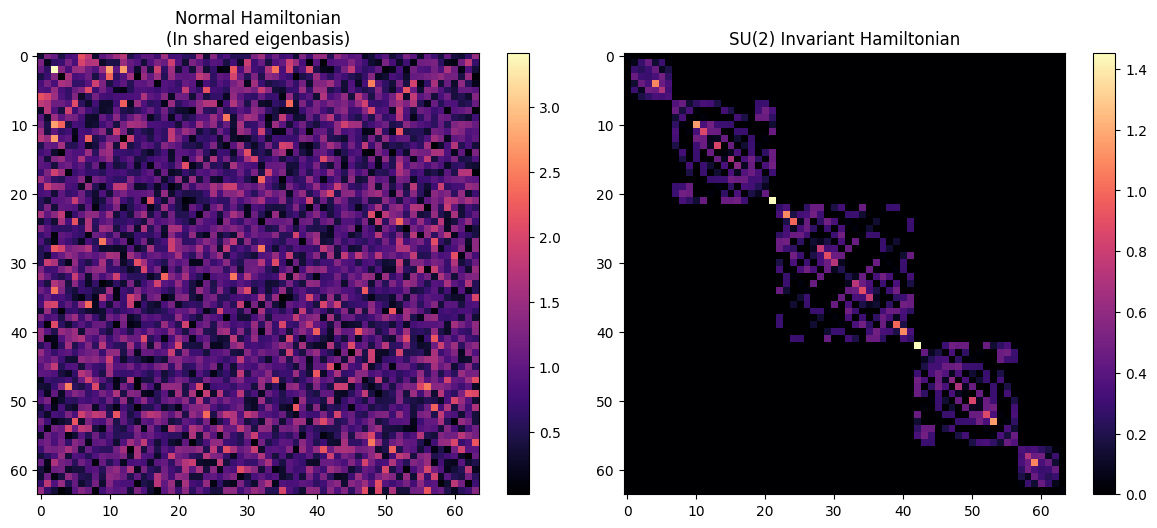

In [6]:
import numpy as np
import matplotlib.pyplot as plt

sx = 0.5 * np.array([[0, 1], [1, 0]], dtype=complex)
sy = 0.5 * np.array([[0, -1j], [1j, 0]], dtype=complex)
sz = 0.5 * np.array([[1, 0], [0, -1]], dtype=complex)
id2 = np.eye(2, dtype=complex)

def get_op(op, site, n_sites):
    res = 1
    for i in range(n_sites):
        if i == site:
            res = np.kron(res, op)
        else:
            res = np.kron(res, id2)
    return res

def build_heisenberg(n_sites):
    H = np.zeros((2**n_sites, 2**n_sites), dtype=complex)
    js = np.random.uniform(-1, 1, n_sites - 1)
    for i in range(n_sites - 1):
        # S_i . S_{i+1}
        J = js[i]
        term = J * (get_op(sx, i, n_sites) @ get_op(sx, i+1, n_sites) +
                get_op(sy, i, n_sites) @ get_op(sy, i+1, n_sites) +
                get_op(sz, i, n_sites) @ get_op(sz, i+1, n_sites))
        H += term
    return H

def build_all_to_all_random_su2(n_sites):
    dim = 2**n_sites
    H = np.zeros((dim, dim), dtype=complex)
    
    for i in range(n_sites):
        for j in range(i + 1, n_sites):
            J = np.random.uniform(-1, 1)
            
            term = J * (get_op(sx, i, n_sites) @ get_op(sx, j, n_sites) +
                        get_op(sy, i, n_sites) @ get_op(sy, j, n_sites) +
                        get_op(sz, i, n_sites) @ get_op(sz, j, n_sites))
            H += term
    return H

def get_total_sz_basis(n_sites):
    sz_vals = []
    for i in range(2**n_sites):
        state_bin = bin(i)[2:].zfill(n_sites)
        val = sum([0.5 if b == '0' else -0.5 for b in state_bin])
        sz_vals.append(val)
    return np.argsort(sz_vals)

n = 6 # 2^6 matrix # TODO: justify why we get N + 1 blocks?
A = np.random.randn(2**n, 2**n) + 1j*np.random.randn(2**n, 2**n)
H_random = (A + A.conj().T) / 2
H_heis = build_all_to_all_random_su2(n)

idx = get_total_sz_basis(n)
H_heis_blocked = H_heis[np.ix_(idx, idx)]
H_random_basis = H_random[np.ix_(idx,idx)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

im1 = ax1.imshow(np.abs(H_random_basis), cmap='magma')
ax1.set_title("Normal Hamiltonian\n(In shared eigenbasis)")
fig.colorbar(im1, ax=ax1)

im2 = ax2.imshow(np.abs(H_heis_blocked), cmap='magma')
ax2.set_title("SU(2) Invariant Hamiltonian")
fig.colorbar(im2, ax=ax2)

plt.tight_layout()
plt.savefig('hamiltonian_comparison.png')
print("Plots saved.")

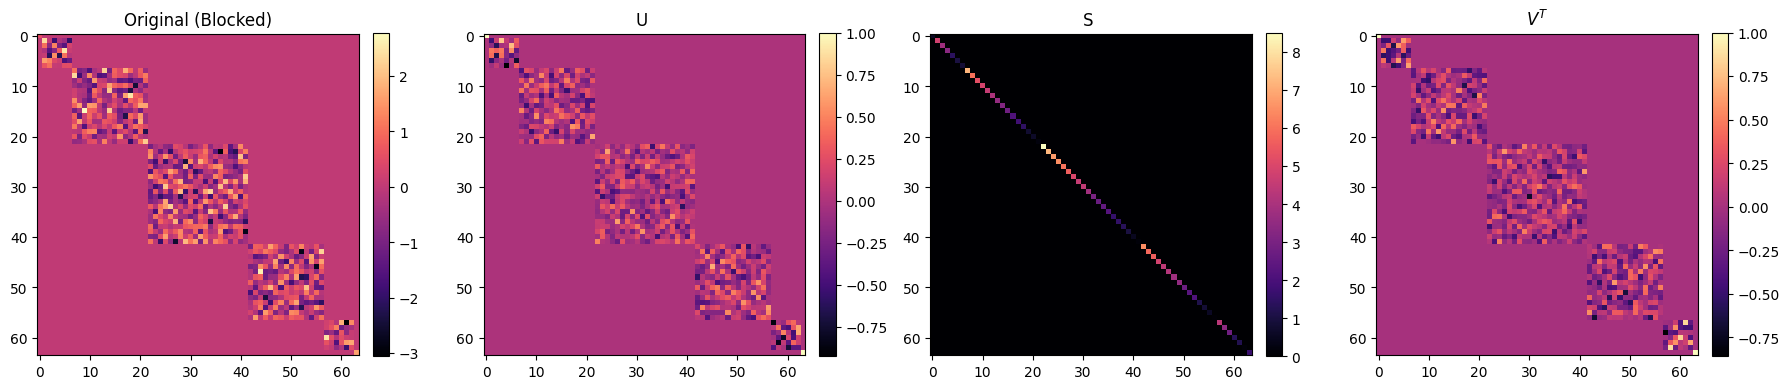

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def create_random_blocked_tensor(n_sites=6):
    blocks = {}
    for i in range(2**n_sites):
        sz = sum([0.5 if b == "0" else -0.5 for b in bin(i)[2:].zfill(n_sites)])
        if sz not in blocks:
            blocks[sz] = []
        blocks[sz].append(i)

    for sz in blocks:
        dim = len(blocks[sz])
        blocks[sz] = np.random.randn(dim, dim)
    return blocks


def blocked_svd(blocked_tensor):
    u_dict, s_dict, vh_dict = {}, {}, {}

    for q, matrix in blocked_tensor.items():
        u, s, vh = np.linalg.svd(matrix, full_matrices=False)

        u_dict[q] = u
        s_dict[q] = s
        vh_dict[q] = vh

    return u_dict, s_dict, vh_dict


def blocks_to_full_matrix(blocked_dict, n_sites=6):
    dim = 2**n_sites
    full_mat = np.zeros((dim, dim))

    current_idx = 0
    for q in sorted(blocked_dict.keys()):
        block = blocked_dict[q]
        b_dim = block.shape[0]
        full_mat[
            current_idx : current_idx + b_dim, current_idx : current_idx + b_dim
        ] = block
        current_idx += b_dim
    return full_mat


n = 6
original_blocks = create_random_blocked_tensor(n)
u_blocks, s_blocks, vh_blocks = blocked_svd(original_blocks)

s_matrices = {q: np.diag(val) for q, val in s_blocks.items()}

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
titles = [
    "Original (Blocked)",
    "U ",
    "S ",
    "$V^T$",
]
data = [original_blocks, u_blocks, s_matrices, vh_blocks]

for ax, d, title in zip(axes, data, titles):
    mat = blocks_to_full_matrix(d, n)
    im = ax.imshow(abs(mat), cmap="magma")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()